# Análise de dataficação em diferentes temas - Congresso ALAS 2026

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as pl
import numpy as np

import brass as br
import xavy.plots as xp

import clean as cl
import datausage as du

## Carregando dados - Agrupando bases originais e do GPT

In [2]:
# Trabalhos acadêmicos analisados (dados de entrada):
folder = '../dados/dspaces/samples/'
sample_files = ["tccs-teses-dissertacoes-outros_ufam_2020-2025_n472_s01.csv", # 7.0% dos trabalhos entre 2020 e 2025 da UF.
                "tccs-teses-dissertacoes_ufcg_2020-2025_n569_s01.csv",        # 7.0% dos trabalhos entre 2020 e 2025 da UF.
                "tccs-teses-dissertacoes_ufes_2020-2025_n323_s01.csv",        # 7.0% dos trabalhos entre 2020 e 2025 da UF.
                "tccs-teses-dissertacoes_ufrgs_2020-2025_n883_s01.csv",       # 3.5% dos trabalhos entre 2020 e 2025 da UF.
                "tccs-dissertacoes-teses_ufpe_2024_0-1000.csv"]               # Primeiros 1000 (de ~4026) trabalhos de 2024 da UF.

In [3]:
# Subconjunto da UFRGS que foi analisada manualmente até a data de análise:
uri_manual = pd.read_csv('../dados/dspaces/samples/aux/urfgs-uris-analisadas-manualmente_2026-05-28.txt', names=['uri'])['uri']
uri_manual = uri_manual.str.replace('http://', 'https://')

In [4]:
# Carrega e junta avaliação da IA:
sel_cols = ['titulo', 'autoria', 'data_publicacao', 'uf', 'resumo', 'uri', 'type_pred', 'topics_pred', 'geo_level_pred', 'y_pred']
results = []
for i in range(len(sample_files)):
    
    # Seleciona arquivo de UF:
    f = folder + sample_files[i]
    uf = re.search('_(uf[a-z]{1,4})_', sample_files[i]).group(1).upper()
    print(uf)
    
    # Carrega os temas e outros metadados criados pelo LLM:
    gpt_jsonl_in  = du.in2out_name(f, in_suffix='.csv', out_suffix='_metadata_gpt-in.jsonl')
    gpt_jsonl_out = du.in2out_name(gpt_jsonl_in)
    single_df = du.build_results_csv(f, gpt_jsonl_in, gpt_jsonl_out, application='metadata_collection')
    # Processa metadados:
    single_df.rename({'uri_link': 'uri', 'data_publicacao_texto': 'data_publicacao', 'ano': 'data_publicacao'}, axis=1, inplace=True)
    single_df['uri'] = single_df['uri'].str.replace('http://', 'https://')
    single_df['uf'] = uf

    # Carrega identificação via LLM de uso de dados públicos:
    gpt_jsonl_in  = du.in2out_name(f, in_suffix='.csv', out_suffix='_gpt-in.jsonl')
    gpt_jsonl_out = du.in2out_name(gpt_jsonl_in)
    y_df = du.build_results_csv(f, gpt_jsonl_in, gpt_jsonl_out, application='usecase_detection')
    # Processa base:
    y_df.rename({'uri_link': 'uri'}, axis=1, inplace=True)
    y_df['uri'] = y_df['uri'].str.replace('http://', 'https://')
    y_df = y_df.set_index('uri')['y_pred']

    # Junta predição de uso de dados com temas e outros metadados:
    single_df = single_df.join(y_df, on='uri')
    
    # Acumula resultados da UF em lista:
    results.append(single_df[sel_cols])

# Concatena UFs:
results_df = pd.concat(results, ignore_index=True)
# Seleciona apenas as verificadas manualmente da UFRGS:
verified_df = results_df.loc[((results_df['uf'] != 'UFRGS') | (results_df['uri'].isin(uri_manual)))]

UFAM
UFCG
UFES
UFRGS
UFPE


In [5]:
# Carrega anotações manuais sobre os casos de uso:
cordata = cl.load_json('../dados/backups/usecases_bkp_2026-06-02.json')
usecases = cordata['data']
usecases_df = pd.DataFrame(usecases)
usecases_df['url'] = usecases_df['url'].str.replace('http://', 'https://')
usecases_df['y_annot'] = 1
usecases_df.rename({'topics':'topics_annot'}, axis=1, inplace=True)
academic_df = usecases_df.loc[usecases_df['type'].apply(lambda s: 'artigo científico ou publicação acadêmica' in s if type(s) == list else False)]

In [6]:
# Nenhum trabalho catalogado no cordata ficou de fora da nossa análise:
assert 0 == pd.Series(list(set(academic_df['url']) - set(verified_df['uri']))).str.contains('ufam|ufcg|ufes|ufrgs', regex=True).sum()

# Junta anotações manuais com base completa:
pred_annot_df = verified_df.join(academic_df.set_index('url')[['topics_annot', 'y_annot']], on='uri')
pred_annot_df['y_annot'] = pred_annot_df['y_annot'].fillna(0).astype(int)

# Classificação sobre uso de dados públicos após sistema LLM + revisão manual:
pred_annot_df['y_final'] = pred_annot_df['y_pred'] * pred_annot_df['y_annot']
# Usa avaliação manual onde houver, senão usa automática:
pred_annot_df['topics_final'] = pred_annot_df['topics_pred'].where(pred_annot_df['topics_annot'].isnull(), pred_annot_df['topics_annot'])

In [7]:
# Salva resultados:
#pred_annot_df.to_csv('../dados/dspaces/testing/trabalhos-academicos-com-metadados_2026-06-08.csv', index=False)

In [8]:
pred_annot_df['y_final'].mean()

np.float64(0.09100758396533044)

In [9]:
pred_annot_df['y_final'].sum()

np.int64(252)

In [10]:
pred_annot_df.query('y_final == 1')['uf'].value_counts()

uf
UFPE     89
UFCG     57
UFRGS    48
UFAM     33
UFES     25
Name: count, dtype: int64

In [11]:
ufpe_use_df = pred_annot_df.query('uf =="UFPE" and y_final == 1')

In [12]:
jac_df = pd.read_csv('/home/hxavier/temp/Trabalhos acadêmicos que usaram dados públicos (segundo GPT) - UFPE 2024 (1-1000).csv')
jac_use_df = jac_df.loc[jac_df['y'] == 1]

In [13]:
set(ufpe_use_df['uri']) - set(jac_use_df['uri'])

{'https://repositorio.ufpe.br/handle/123456789/55633',
 'https://repositorio.ufpe.br/handle/123456789/55857',
 'https://repositorio.ufpe.br/handle/123456789/56037'}

In [14]:
set(jac_use_df['uri']) - set(ufpe_use_df['uri'])

set()

### Visualização gráfica da frequência de temas e seleção dos 20 temas mais comuns

Vamos considerar os vinte temas mais trabalhados:

# de trabalhos acadêmicos considerados: 2769


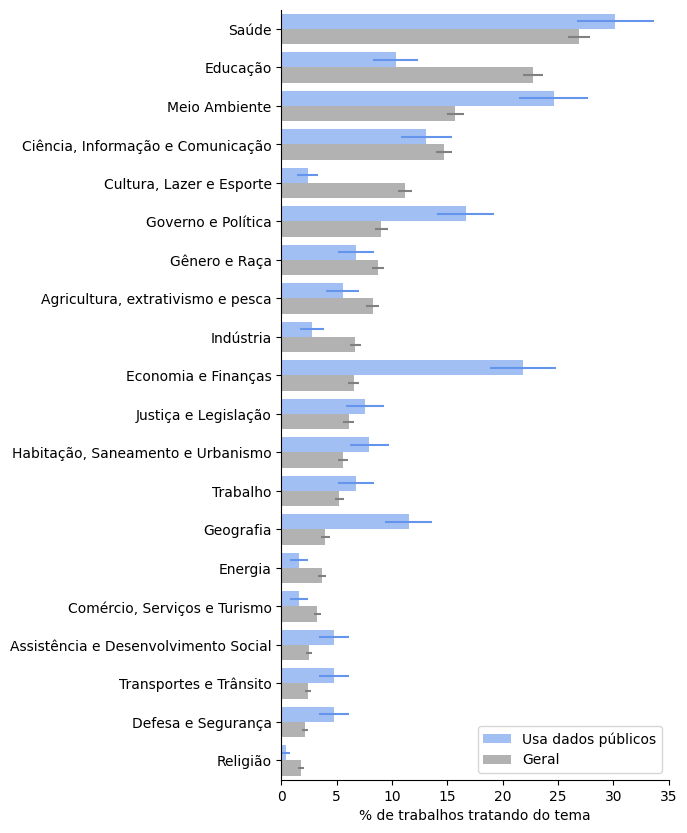

In [26]:
top_k = 20
# Contagem de aparições de temas nos trabalhos acadêmicos e seleção dos 20 primeiros:
pred_counts = pred_annot_df['topics_pred'].explode().value_counts().head(top_k)
n_all = len(pred_annot_df)
# Identificação dos 20 temas mais comuns:
topics_list = list(pred_counts.index)
print('# de trabalhos acadêmicos considerados:', n_all)
# Coloca contagem numa tabela:
counts_df = pd.DataFrame()
counts_df['Geral'] = pred_counts
counts_df.sort_values('Geral', inplace=True)
# Cria tabela de frequência:
freqs_df = counts_df / n_all * 100
# Cria tabela de desvio padrão (aprox.) para frequências:
freq_err_df = pd.DataFrame()
freq_err_df['Geral'] = np.sqrt(counts_df['Geral']) / n_all * 100

# Seleciona apenas trabalhos que usam dados:
use_df = pred_annot_df.loc[pred_annot_df['y_final'] == 1]
# Contabiliza temas preditos pela IA:
use_counts = use_df['topics_pred'].explode().value_counts()
use_counts = use_counts.loc[use_counts.index.isin(topics_list)]
# Adiciona na tabela:
counts_df['Usa dados públicos'] = use_counts
counts_df['Usa dados públicos'] = counts_df['Usa dados públicos'].fillna(0).astype(int)
# Calcula frequências e coloca na tabela de frequências:
n_use = len(use_df)
freqs_df['Usa dados públicos'] = use_counts / n_use * 100
freqs_df['Usa dados públicos'] = freqs_df['Usa dados públicos'].fillna(0)
# Calcula desvio padrão (aprox.) para frequências:
freq_err_df['Usa dados públicos'] = np.sqrt(counts_df['Usa dados públicos'].clip(lower=1)) / n_use * 100

pl.figure(figsize=(5,10))
xp.multiple_bars_plot(freqs_df, horizontal=True, err=freq_err_df, colors=['0.5', 'cornflowerblue'], alpha=0.6)
handles, labels = pl.gca().get_legend_handles_labels()
pl.legend(handles[::-1], labels[::-1])
pl.xlabel('% de trabalhos tratando do tema')
pl.xlim([0, 35])
ax = pl.gca()
pl.ylim([-0.5, 19.5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
#pl.savefig('../resultados/2026-07_ALAS/imagens/frequencia-temas-vs-uso-de-dados.png', dpi=900, bbox_inches='tight')
pl.show()

In [30]:
freqs_df.sort_values('Geral', ascending=False).head()

,Geral,Usa dados públicos
topics_pred,,
Saúde,26.905020,30.158730
Educação,22.751896,10.317460
Meio Ambiente,15.709642,24.603175
"Ciência, Informação e Comunicação",14.662333,13.095238
"Cultura, Lazer e Esporte",11.159263,2.380952


In [29]:
freqs_df.sort_values('Usa dados públicos', ascending=False).head()

,Geral,Usa dados públicos
topics_pred,,
Saúde,26.905020,30.158730
Meio Ambiente,15.709642,24.603175
Economia e Finanças,6.536656,21.825397
Governo e Política,9.028530,16.666667
"Ciência, Informação e Comunicação",14.662333,13.095238


## Análise de associação entre uso de dados públicos e temas

In [13]:
# Loop sobre método de rotulação (automático, automático + manual):
# Loop sobre temas:
dfs = []
for topic in topics_list:
    # Seleciona colunas (uso de dados e tema):
    col_A = 'y_final'
    col_B = topic
    pair_df = pred_annot_df[[col_A]]
    pair_df[col_B] = pred_annot_df['topics_pred'].apply(lambda s: col_B in s).astype(int)
    # Roda teste estatístico de associação:
    estimator = br.AssocEstimator(onehot_trials=pair_df)
    chain_df = estimator.sample_model()
    df = estimator.summarize_stats(chain_df, 'Usa dados', col_B)
    dfs.append(df)
# Junta resultados dos temas:
assoc_df = pd.concat(dfs, axis=0)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pair_probs]


Output()

Sampling 4 chains for 1_000 tune and 2_500 draw iterations (4_000 + 10_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pair_probs]


Output()

Sampling 4 chains for 1_000 tune and 2_500 draw iterations (4_000 + 10_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pair_probs]


...

Sampling 4 chains for 1_000 tune and 2_500 draw iterations (4_000 + 10_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pair_probs]


Output()

Sampling 4 chains for 1_000 tune and 2_500 draw iterations (4_000 + 10_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pair_probs]


Output()

Sampling 4 chains for 1_000 tune and 2_500 draw iterations (4_000 + 10_000 draws total) took 3 seconds.


In [14]:
alpha_single = 0.05
# Correção para o problema das comparações múltiplas:
alpha_bonferroni = alpha_single / len(topics_list)

detected = dict()
undetected = dict()
positive_assoc = dict()
negative_assoc = dict()
# Seleciona associações estatisticamente significativas:
detected_df = assoc_df.loc[assoc_df['delta p-value'] < alpha_bonferroni]
# Seleciona as demais:
undetected_df = assoc_df.loc[assoc_df['delta p-value'] > alpha_bonferroni]
# Dentre as significativas, separa as positivas das negativas:
positive_assoc_df = detected_df.loc[detected_df['deltaP(A,B)'] > 0]
negative_assoc_df = detected_df.loc[detected_df['deltaP(A,B)'] < 0]

In [15]:
# Seleciona tópicos com associação a dados positiva ou negativa:
positive_topics = set(positive_assoc_df.query('Direction == "F"')['B'])
negative_topics = set(negative_assoc_df.query('Direction == "F"')['B'])

In [16]:
print(positive_topics)

{'Meio Ambiente', 'Defesa e Segurança', 'Geografia', 'Economia e Finanças', 'Governo e Política'}


In [17]:
print(negative_topics)

{'Educação', 'Cultura, Lazer e Esporte'}


In [22]:
positive_assoc_df.loc[positive_assoc_df['B'].isin(positive_topics)].sort_values('P(A|B)', ascending=False)

,Direction,A,B,P(A),dev P(A),P(A|B),dev P(A|B),"deltaP(A,B)","dev deltaP(A,B)",abs delta nsigma,delta p-value
0,F,Usa dados,Economia e Finanças,0.091524,0.005413,0.305426,0.033335,0.213902,0.031569,6.775744,0.0000
0,F,Usa dados,Geografia,0.091597,0.005441,0.267747,0.041970,0.176150,0.040554,4.343621,0.0000
0,F,Usa dados,Defesa e Segurança,0.091672,0.005510,0.210082,0.051396,0.118410,0.050505,2.344536,0.0022
0,F,Usa dados,Governo e Política,0.091673,0.005577,0.170705,0.023696,0.079032,0.022105,3.575381,0.0000
0,F,Usa dados,Meio Ambiente,0.091569,0.005511,0.144162,0.016481,0.052592,0.014721,3.572485,0.0001


In [23]:
negative_assoc_df.loc[negative_assoc_df['B'].isin(negative_topics)].sort_values('P(A|B)', ascending=False)

,Direction,A,B,P(A),dev P(A),P(A|B),dev P(A|B),"deltaP(A,B)","dev deltaP(A,B)",abs delta nsigma,delta p-value
0,F,Usa dados,Educação,0.091589,0.005506,0.042716,0.00812,-0.048873,0.008148,5.998562,0.0
0,F,Usa dados,"Cultura, Lazer e Esporte",0.091509,0.005535,0.022231,0.00821,-0.069278,0.009242,7.495612,0.0


In [24]:
# Casos sem significância suficiente para garantir detecção:
undetected_df.query('Direction == "F"')

,Direction,A,B,P(A),dev P(A),P(A|B),dev P(A|B),"deltaP(A,B)","dev deltaP(A,B)",abs delta nsigma,delta p-value
0,F,Usa dados,Saúde,0.091558,0.005491,0.102975,0.011117,0.011418,0.009257,1.233356,0.1050
0,F,Usa dados,"Ciência, Informação e Comunicação",0.091497,0.005501,0.083334,0.013648,-0.008163,0.012763,0.639611,0.2537
0,F,Usa dados,Gênero e Raça,0.091645,0.005410,0.073519,0.016588,-0.018126,0.016027,1.130995,0.1358
0,F,Usa dados,"Agricultura, extrativismo e pesca",0.091667,0.005445,0.065508,0.016210,-0.026159,0.015784,1.657332,0.0595
0,F,Usa dados,Indústria,0.091528,0.005494,0.042476,0.015000,-0.049052,0.014957,3.279521,0.0037
0,F,Usa dados,Justiça e Legislação,0.091665,0.005489,0.117970,0.024908,0.026305,0.023926,1.099430,0.1322
0,F,Usa dados,"Habitação, Saneamento e Urbanismo",0.091627,0.005522,0.134162,0.027009,0.042535,0.025996,1.636214,0.0386
0,F,Usa dados,Trabalho,0.091520,0.005500,0.121824,0.026617,0.030304,0.025816,1.173862,0.1145
0,F,Usa dados,Energia,0.091667,0.005462,0.048401,0.020910,-0.043266,0.020881,2.071986,0.0334
0,F,Usa dados,"Comércio, Serviços e Turismo",0.091554,0.005472,0.053636,0.023274,-0.037918,0.023167,1.636729,0.0647


## Análise da evolução temporal

In [15]:
from sklearn.linear_model import LinearRegression

In [16]:
# Prepare data:
temp_df = pred_annot_df.query('uf != "UFPE"').copy()
temp_df['ano'] = temp_df['data_publicacao'].str.slice(0,4)

In [22]:
# Prepare for resampling:
n_samples = 10000
n_temp = len(temp_df)
lmodel = LinearRegression()

# Loop over resamples:
temp_data = []
for _ in range(n_samples):
    # Resample with replacement:
    temp_resample_df = temp_df.sample(n_temp, replace=True)
    # Compute fraction that uses data, per year:
    tot_by_year_counts = temp_resample_df['ano'].value_counts().sort_index()
    use_by_year_counts = temp_resample_df.query('y_final == 1')['ano'].value_counts().sort_index()
    use_by_year_frac = use_by_year_counts / tot_by_year_counts
    # Fit linear model and store the trend:
    X = np.transpose([use_by_year_frac.index.astype(float)]) - np.array(use_by_year_frac.index.astype(float)).mean()
    lmodel.fit(X, use_by_year_frac)
    temp_data.append({'coef': lmodel.coef_[0], 'intercept': lmodel.intercept_})

# Put resamples in table:
resampling_temp_df = pd.DataFrame(temp_data)

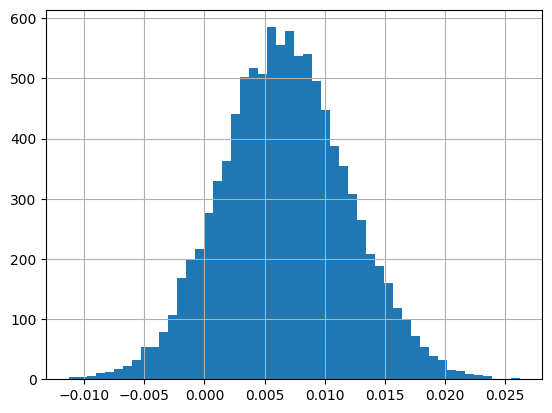

In [24]:
resampling_temp_df['coef'].hist(bins=50);

In [25]:
(resampling_temp_df['coef'] < 0).mean()

np.float64(0.1007)

# Lixo

In [14]:
n_samples = 10000
samples = []
for i in range(n_samples):
    s = verified_df.sample(n_use_pred)['topics_pred'].explode().value_counts()
    s.name = i
    samples.append(s)

samples_df = pd.concat(samples, axis=1).fillna(0).astype(int)
samples_df = samples_df.loc[samples_df.index.isin(all_counts.index)]

In [27]:
samples_df

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
topics_pred,,,,,,,,,,,,,,,,,,,,,
Educação,46,53,54,43,41,53,45,52,46,55,...,40,45,50,48,52,45,56,48,47,37
Saúde,46,39,39,40,53,34,46,36,43,42,...,48,49,41,46,38,47,39,58,50,41
"Ciência, Informação e Comunicação",26,35,27,22,20,27,26,23,30,29,...,18,24,22,29,23,38,22,25,24,24
"Cultura, Lazer e Esporte",26,24,26,25,21,23,27,24,23,23,...,16,19,27,32,21,22,27,14,21,25
Governo e Política,24,14,14,15,20,25,19,23,22,23,...,22,21,15,17,15,21,18,17,18,20
Meio Ambiente,24,27,34,30,23,26,36,33,32,28,...,28,36,40,37,30,32,31,36,30,34
Gênero e Raça,23,21,25,22,19,14,22,15,24,10,...,17,22,18,16,21,22,22,18,18,23
Indústria,19,16,12,11,15,17,12,20,14,10,...,15,10,13,16,12,17,14,15,14,12
"Agricultura, extrativismo e pesca",18,20,17,20,21,23,14,27,14,16,...,22,20,28,26,27,18,22,22,23,23


In [28]:
use_pred_counts

topics_pred
Saúde                                   52
Meio Ambiente                           51
Economia e Finanças                     34
Governo e Política                      34
Ciência, Informação e Comunicação       30
Educação                                21
Justiça e Legislação                    19
Geografia                               19
Habitação, Saneamento e Urbanismo       16
Trabalho                                15
Agricultura, extrativismo e pesca       13
Transportes e Trânsito                  13
Defesa e Segurança                      12
Gênero e Raça                           11
Assistência e Desenvolvimento Social     6
Cultura, Lazer e Esporte                 6
Indústria                                6
Comércio, Serviços e Turismo             4
Energia                                  1
Name: count, dtype: int64

In [23]:
samples_df

,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
topics_pred,,,,,,,,,,,,,,,,,,,,,
Educação,46,53,54,43,41,53,45,52,46,55,...,40,45,50,48,52,45,56,48,47,37
Saúde,46,39,39,40,53,34,46,36,43,42,...,48,49,41,46,38,47,39,58,50,41
"Ciência, Informação e Comunicação",26,35,27,22,20,27,26,23,30,29,...,18,24,22,29,23,38,22,25,24,24
"Cultura, Lazer e Esporte",26,24,26,25,21,23,27,24,23,23,...,16,19,27,32,21,22,27,14,21,25
Governo e Política,24,14,14,15,20,25,19,23,22,23,...,22,21,15,17,15,21,18,17,18,20
Meio Ambiente,24,27,34,30,23,26,36,33,32,28,...,28,36,40,37,30,32,31,36,30,34
Gênero e Raça,23,21,25,22,19,14,22,15,24,10,...,17,22,18,16,21,22,22,18,18,23
Indústria,19,16,12,11,15,17,12,20,14,10,...,15,10,13,16,12,17,14,15,14,12
"Agricultura, extrativismo e pesca",18,20,17,20,21,23,14,27,14,16,...,22,20,28,26,27,18,22,22,23,23
